In [1]:
import os
import torch
from torch import nn
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [2]:
os.chdir('../')

In [3]:
from src.LinearRegression import LinearRegression

### Pipeline de Treino
1. Modelo (input size, output size, forward pass)
2. Loss e Otimizador
3. Loop de Treino
    - Forward pass
    - Calcula Loss
    - Backward pass
    - Atualiza pesos

In [4]:
# 0. Preparação de dados
X_numpy, y_numpy = datasets.make_regression(n_samples=100, n_features=1, noise=10, random_state=1)

In [5]:
type(X_numpy)

numpy.ndarray

In [6]:
X_data = torch.from_numpy(X_numpy.astype(np.float32))
y_data = torch.from_numpy(y_numpy.astype(np.float32))

In [7]:
# 1. Modelo
model = LinearRegression(n_input=1)

In [8]:
# 2. Loss e Otimizador
learning_rate = 0.001
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [9]:
# 3. Loop de Treino
num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass
    y_pred = model(X_data)

    # Calcula Loss
    loss = criterion(y_pred, y_data)

    # Backward pass
    loss.backward()

    # Update
    optimizer.step()
    optimizer.zero_grad()

c:\Users\roger\OneDrive\Documentos\Coding Repos\PyTorch\env\Lib\site-packages\torch\nn\modules\loss.py:630: UserWarning: Using a target size (torch.Size([100])) that is different to the input size (torch.Size([100, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


### Avaliação

In [10]:
predicted = model(X_data).detach().numpy()

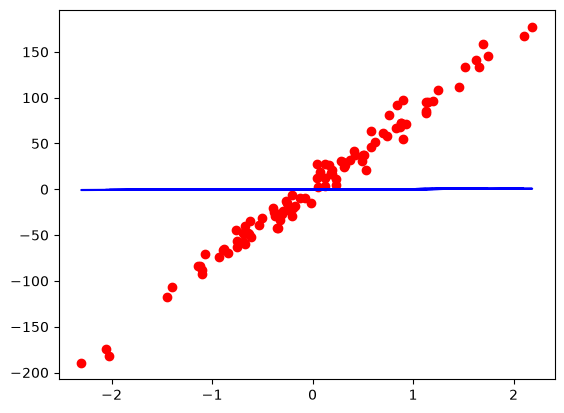

In [11]:
plt.plot(X_numpy, y_numpy, 'ro')
plt.plot(X_numpy, predicted, 'b')
plt.show()